In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [73]:
df = pd.read_csv(r"C:\Users\rachi\Downloads\titanic.csv")

In [74]:
df.shape

(891, 12)

In [75]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [76]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='mean')
df[['Age']]=si.fit_transform(df[['Age']])

In [77]:
s = SimpleImputer(strategy = 'most_frequent')
df[['Embarked']]=s.fit_transform(df[['Embarked']])

In [78]:
df=df.drop('Cabin',axis=1)

In [79]:
df=df.drop(['Name','PassengerId'],axis=1)

In [80]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [84]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype=='object':
        df[i]=le.fit_transform(df[i])

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


<Axes: >

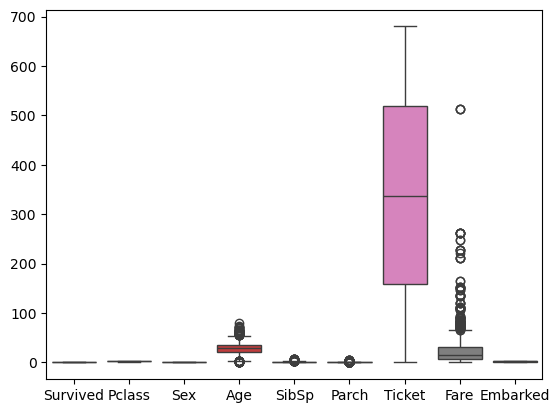

In [86]:
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))

In [87]:
X= df.drop('Survived',axis=1)
y= df['Survived']

In [109]:

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df[['Age','SibSp','Parch','Fare']]=ss.fit_transform(df[['Age','SibSp','Parch','Fare']])
d = df[['Age','SibSp','Parch','Fare']]
for i in d:
    low = df[i].quantile(0.25)
    up = df[i].quantile(0.75)
    df[i]=df[i].clip(low,up)

<Axes: >

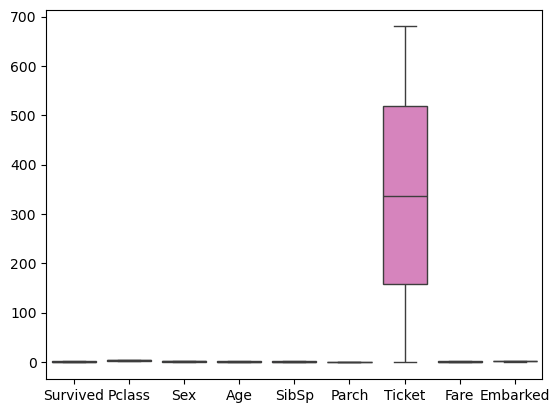

In [110]:
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))

In [111]:
rf = RandomForestClassifier(n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    criterion='entropy',
    random_state=42)

In [112]:
from sklearn.model_selection import train_test_split
Xt,Xte,yt,yte=train_test_split(X,y,test_size=0.2,random_state=42)


In [113]:
rf.fit(Xt,yt)

,n_estimators,200
,criterion,'entropy'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [114]:
yp=rf.predict(Xte)

In [115]:
from sklearn.metrics import classification_report as cr
print(cr(yte,yp))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.84      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

